# Stage 1D: Chart Type Classification (ResNet-18)

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 2.0.0 | 2026-01-28 | That Le | ResNet-18 classification only |

---

## Purpose

**Input:** Detected charts from `detected_charts/` (output of 01c)

**Output:** Charts organized by type in `classified_charts/{bar,line,pie,...}/`

### Pipeline

```
01c: YOLO detect --> detected_charts/ (~2,500 charts)
        |
[01d_chart_classification]  <-- This notebook
        |
        +-- ResNet-18 classify chart type
        |
        v
classified_charts/
  ├── bar/
  ├── line/
  ├── pie/
  ├── scatter/
  ├── ... (other types)
  └── uncertain/  (low confidence)
```

### Model Info

| Model | Classes | Val Accuracy |
| --- | --- | --- |
| ResNet-18 | area, bar, box, heatmap, histogram, line, pie, scatter | 96.9% |

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================

RESNET_CONFIDENCE = 0.7   # Min confidence for classification
EXECUTE_PIPELINE = True   # Set False for dry run

print(f"Mode: {'ACTIVE' if EXECUTE_PIPELINE else 'DRY RUN'}")
print(f"ResNet confidence threshold: {RESNET_CONFIDENCE}")

Mode: ACTIVE
ResNet confidence threshold: 0.7


In [2]:
# ============================================================================
# SETUP
# ============================================================================
import sys
from pathlib import Path
from datetime import datetime
import json
import shutil

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Input: Detected charts from 01c
INPUT_DIR = PROJECT_ROOT / "data" / "academic_dataset" / "detected_charts"

# Output: Organized by type
OUTPUT_DIR = PROJECT_ROOT / "data" / "academic_dataset" / "classified_charts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input:  {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")

Input:  d:\elix\chart_analysis_ai_v3\data\academic_dataset\detected_charts
Output: d:\elix\chart_analysis_ai_v3\data\academic_dataset\classified_charts


In [3]:
# ============================================================================
# CHECK INPUT
# ============================================================================

input_images = list(INPUT_DIR.glob("*.png")) + list(INPUT_DIR.glob("*.jpg"))

print("=" * 50)
print("INPUT STATUS")
print("=" * 50)
print(f"Charts to classify: {len(input_images):,}")
print("=" * 50)

if len(input_images) == 0:
    print("\n[WARNING] No images found!")
    print(f"Run 01c_chart_detection.ipynb first.")

INPUT STATUS
Charts to classify: 50,865


In [4]:
# ============================================================================
# LOAD RESNET-18 CLASSIFIER
# ============================================================================
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load model
resnet_path = PROJECT_ROOT / "models" / "weights" / "resnet18_chart_classifier_best.pt"

if not resnet_path.exists():
    raise FileNotFoundError(f"ResNet model not found: {resnet_path}")

checkpoint = torch.load(resnet_path, map_location=device, weights_only=False)

# Get class mapping
class_mapping = checkpoint.get("class_mapping", {})
CHART_TYPES = [k for k, v in sorted(class_mapping.items(), key=lambda x: x[1])]
print(f"Chart types: {CHART_TYPES}")

# Build model
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CHART_TYPES))

# Load weights
state_dict = checkpoint.get("model_state_dict", checkpoint)
if any(k.startswith("resnet.") for k in state_dict.keys()):
    state_dict = {k.replace("resnet.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.to(device).eval()

print(f"ResNet-18 loaded | val_acc={checkpoint.get('val_acc', 'N/A')}%")

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

Device: cuda
Chart types: ['area', 'bar', 'box', 'heatmap', 'histogram', 'line', 'pie', 'scatter']
ResNet-18 loaded | val_acc=96.875%


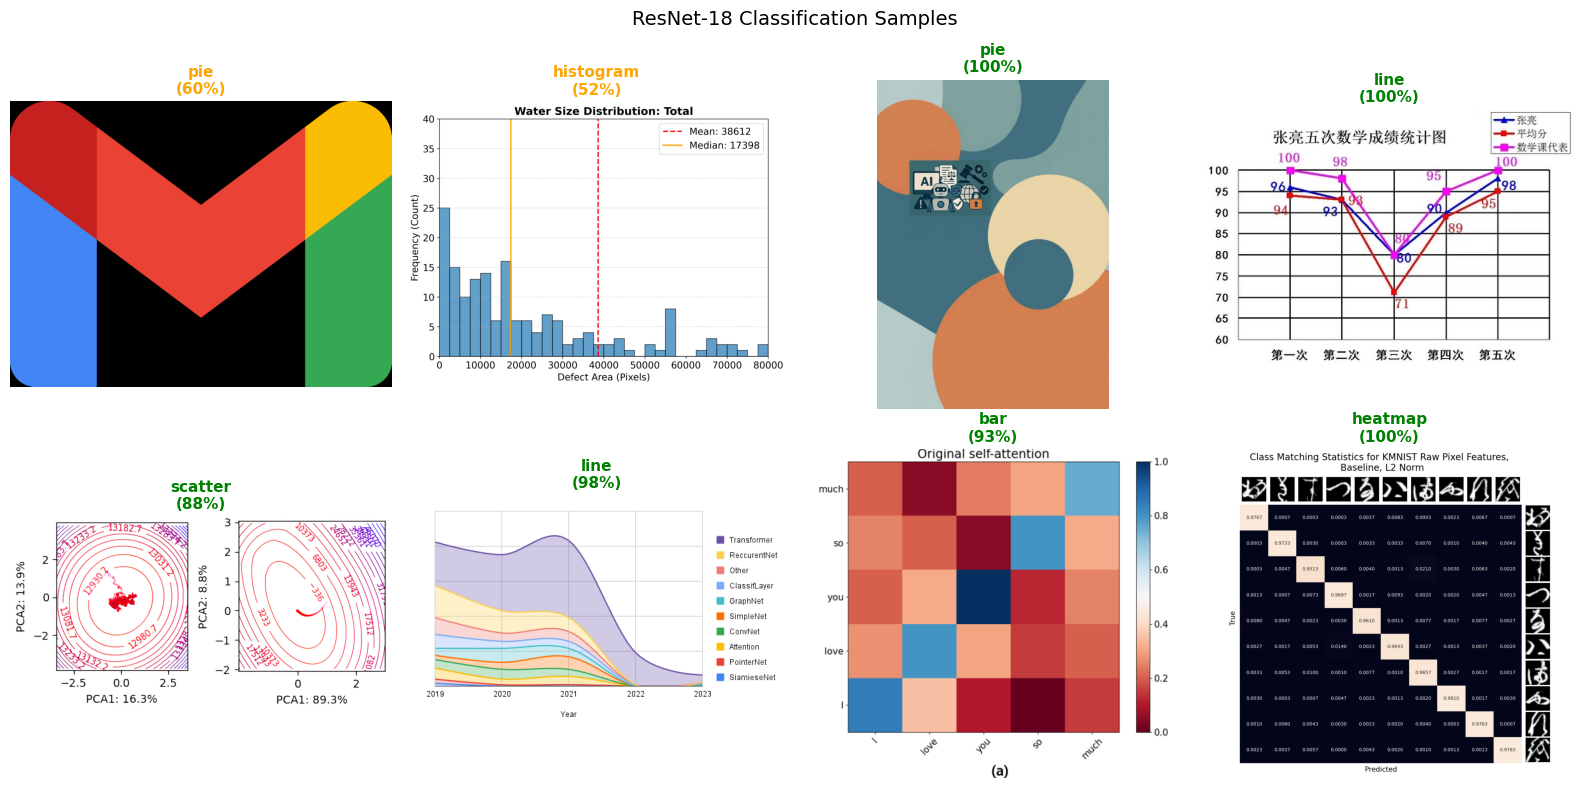

In [5]:
# ============================================================================
# TEST ON SAMPLES
# ============================================================================
import random
import matplotlib.pyplot as plt


def classify_chart(image_path: Path):
    """Classify single chart image."""
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        conf, pred_idx = probs.max(0)
    
    return CHART_TYPES[pred_idx.item()], conf.item()


# Random samples
if input_images:
    samples = random.sample(input_images, min(8, len(input_images)))
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for ax, img_path in zip(axes, samples):
        chart_type, conf = classify_chart(img_path)
        
        img = Image.open(img_path)
        ax.imshow(img)
        
        color = "green" if conf >= RESNET_CONFIDENCE else "orange"
        ax.set_title(f"{chart_type}\n({conf:.0%})", color=color, fontsize=11, fontweight="bold")
        ax.axis("off")
    
    plt.suptitle("ResNet-18 Classification Samples", fontsize=14)
    plt.tight_layout()
    plt.show()

In [6]:
# ============================================================================
# BATCH CLASSIFICATION
# ============================================================================
from tqdm.auto import tqdm
import time
from typing import Dict


def classify_and_organize(
    input_dir: Path,
    output_dir: Path,
    min_confidence: float = 0.7,
    dry_run: bool = True,
) -> Dict:
    """
    Classify charts and organize by type.
    """
    images = list(input_dir.glob("*.png")) + list(input_dir.glob("*.jpg"))
    
    print("=" * 60)
    print(f"CHART CLASSIFICATION | {'DRY RUN' if dry_run else 'ACTIVE'}")
    print(f"Images: {len(images):,}")
    print(f"Min confidence: {min_confidence:.0%}")
    print("=" * 60)
    
    if dry_run:
        print("\n[DRY RUN] Set EXECUTE_PIPELINE = True to run.")
        return {}
    
    # Create subdirs for each type
    for ct in CHART_TYPES + ["uncertain"]:
        (output_dir / ct).mkdir(parents=True, exist_ok=True)
    
    results = []
    by_type = {ct: 0 for ct in CHART_TYPES + ["uncertain"]}
    
    start = time.time()
    
    for img_path in tqdm(images, desc="Classifying"):
        try:
            chart_type, confidence = classify_chart(img_path)
            
            # Determine destination
            dest_type = chart_type if confidence >= min_confidence else "uncertain"
            
            # Copy to type folder
            dest_path = output_dir / dest_type / img_path.name
            shutil.copy2(img_path, dest_path)
            
            by_type[dest_type] += 1
            
            results.append({
                "image": img_path.name,
                "type": chart_type,
                "confidence": round(confidence, 4),
                "dest": dest_type,
            })
            
        except Exception as e:
            print(f"Error: {img_path.name} - {e}")
    
    elapsed = time.time() - start
    
    # Save results
    results_path = output_dir / "classification_results.json"
    with open(results_path, "w") as f:
        json.dump({"results": results, "by_type": by_type}, f, indent=2)
    
    print("\n" + "=" * 60)
    print("CLASSIFICATION COMPLETE")
    print(f"Time: {elapsed:.1f}s ({len(images)/elapsed:.1f} img/s)")
    print("-" * 60)
    print("Distribution:")
    for ct, count in sorted(by_type.items(), key=lambda x: -x[1]):
        if count > 0:
            pct = count / len(images) * 100
            print(f"  {ct:12s}: {count:5,} ({pct:5.1f}%)")
    print("=" * 60)
    
    return {"results": results, "by_type": by_type}

d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ============================================================================
# EXECUTE CLASSIFICATION
# ============================================================================

if EXECUTE_PIPELINE and len(input_images) > 0:
    classification_results = classify_and_organize(
        input_dir=INPUT_DIR,
        output_dir=OUTPUT_DIR,
        min_confidence=RESNET_CONFIDENCE,
        dry_run=False,
    )
else:
    classification_results = {}
    print("[SKIPPED]")

CHART CLASSIFICATION | ACTIVE
Images: 50,865
Min confidence: 70%


Classifying:  65%|██████▍   | 32944/50865 [15:23<13:58, 21.37it/s] d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (142846009 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Classifying:  66%|██████▌   | 33506/50865 [15:46<09:33, 30.27it/s]d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (93146604 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Classifying:  82%|████████▏ | 41561/50865 [21:37<07:24, 20.93it/s]d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (103680000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Classifying:  85%|████████▍ | 43002/50865 [22:40<07:44, 16.93it/s]d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: Decompr


CLASSIFICATION COMPLETE
Time: 1683.1s (30.2 img/s)
------------------------------------------------------------
Distribution:
  line        : 16,154 ( 31.8%)
  uncertain   : 10,326 ( 20.3%)
  bar         : 8,587 ( 16.9%)
  scatter     : 7,615 ( 15.0%)
  heatmap     : 4,227 (  8.3%)
  pie         : 1,299 (  2.6%)
  box         : 1,051 (  2.1%)
  histogram   :   882 (  1.7%)
  area        :   724 (  1.4%)


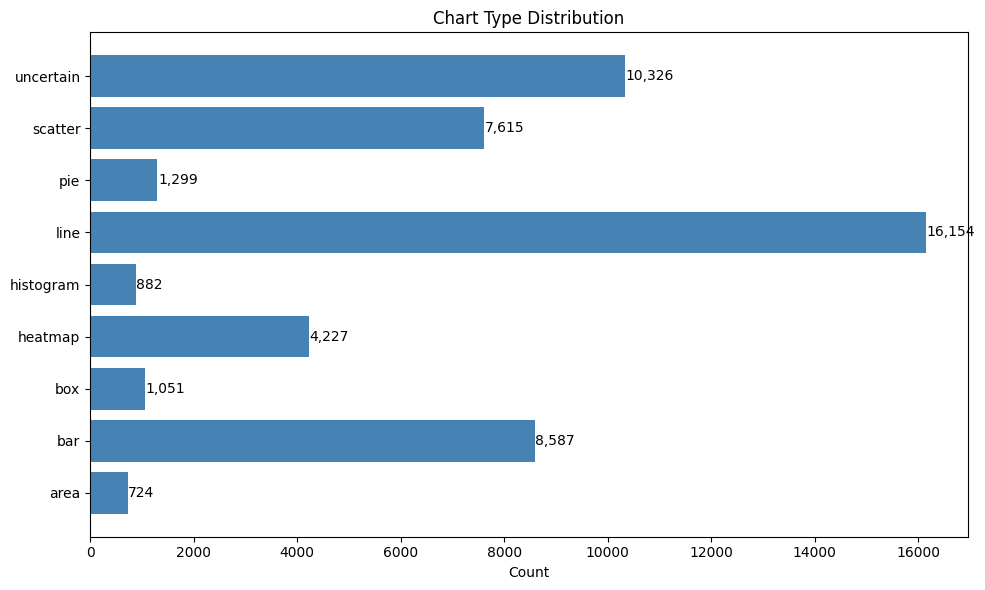

In [8]:
# ============================================================================
# VISUALIZATION
# ============================================================================
import matplotlib.pyplot as plt

if classification_results:
    by_type = classification_results["by_type"]
    
    # Filter non-zero
    types = [t for t, c in by_type.items() if c > 0]
    counts = [by_type[t] for t in types]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(types, counts, color="steelblue")
    ax.set_xlabel("Count")
    ax.set_title("Chart Type Distribution")
    
    # Add count labels
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
                f"{count:,}", va="center", fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [9]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("=" * 60)
print("CLASSIFICATION SUMMARY")
print("=" * 60)
print(f"\nOutput: {OUTPUT_DIR}/")

total = 0
for ct in CHART_TYPES + ["uncertain"]:
    ct_dir = OUTPUT_DIR / ct
    if ct_dir.exists():
        count = len(list(ct_dir.glob("*.png"))) + len(list(ct_dir.glob("*.jpg")))
        if count > 0:
            print(f"  {ct}/  ({count:,})")
            total += count

print(f"\nTotal: {total:,} charts classified")
print("=" * 60)
print("\nNEXT STEPS:")
print("1. Review 'uncertain/' folder for misclassified charts")
print("2. Use classified data for Stage 3 (OCR) and Stage 4 (SLM)")

CLASSIFICATION SUMMARY

Output: d:\elix\chart_analysis_ai_v3\data\academic_dataset\classified_charts/
  area/  (724)
  bar/  (8,587)
  box/  (1,051)
  heatmap/  (4,227)
  histogram/  (882)
  line/  (16,154)
  pie/  (1,299)
  scatter/  (7,615)
  uncertain/  (10,326)

Total: 50,865 charts classified

NEXT STEPS:
1. Review 'uncertain/' folder for misclassified charts
2. Use classified data for Stage 3 (OCR) and Stage 4 (SLM)


---

## Summary

**Pipeline completed:**

| Stage | Task | Output |
| --- | --- | --- |
| 01a | Data collection | PDFs downloaded |
| 01b | Image extraction | ~200k images |
| 01c | YOLO detection | ~2,500 charts |
| 01d | ResNet classification | Charts by type |

**Next: Core Pipeline**

- Stage 2: Detection refinement
- Stage 3: OCR + Element extraction
- Stage 4: SLM reasoning